# Day 2 — 로그수익률 + 6국면 분포 통계

로직은 `src/returns.py`에 있고, 이 노트북은 실행·검증·시각화만 한다
(CLAUDE.md: 로직은 `src/`, 실행·탐색은 `notebooks/`).

- `add_log_return()` — 티커별 로그수익률 (groupby("ticker") + shift(1))
- `phase_statistics()` — 국면별 누적/연율수익률, 연율변동성, 왜도, 초과첨도, MDD

**국면 라벨은 사후(post-hoc) 정보다.** `config.MARKET_REGIMES`의 구간 경계는
지나고 나서야 확정된 날짜라, 매매 규칙 안에 넣는 순간 미래 참조가 된다
(CLAUDE.md 규칙 4). 오늘은 분포를 묘사하는 용도로만 쓴다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# 노트북은 notebooks/ 안에서 실행되므로 sys.path에 프로젝트 루트가 없다.
PROJECT_ROOT = Path.cwd().parent  # -> Path (프로젝트 루트)
ROOT_TEXT = str(PROJECT_ROOT)     # -> str

if ROOT_TEXT not in sys.path:
    sys.path.insert(0, ROOT_TEXT)

from src import config, data, returns

# D1에서 굳혀둔 원본 스냅샷을 읽는다. 수정주가는 오늘 기준으로 매번 재계산되므로
# yfinance를 다시 부르지 않고 이 parquet만 쓴다 (CLAUDE.md 재현성 규칙).
df = data.load_parquet(config.RAW_OHLCV_PATH)  # -> DataFrame (18424, 8)
df.shape

2026-08-03 15:16:01,002 [INFO] 로드 완료: C:\Users\chris\projects\sp500-technical-strategy\data\raw\ohlcv_raw.parquet (18424행)


(18424, 8)

## 1. 로그수익률 계산

`add_log_return()`은 `groupby("ticker")` 안에서 `shift(1)`을 걸어 전날 종가를
가져온다. 이 데이터에는 티커가 2개 세로로 쌓여 있어서, ticker를 무시하고
`shift(1)`을 걸면 `^GSPC` 마지막 행(2026-07-31, 7489.72)과 `^SP500TR` 첫
행(1990-01-02, 386.16)이 비교되어 로그수익률 **-2.965**(단순수익률로 환산하면
하루 만에 **-94.8%**)라는, 현실에 존재한 적 없는 값이 만들어진다.

In [2]:
df = returns.add_log_return(df)  # -> DataFrame (18424, 9)

show_columns = ["date", "ticker", "close", "log_return"]  # -> list[str] (4,)
df[show_columns].head(3)

,date,ticker,close,log_return
0,1990-01-02,^GSPC,359.690002,NaN
1,1990-01-03,^GSPC,358.760010,-0.002589
2,1990-01-04,^GSPC,355.670013,-0.008650


In [3]:
# 티커 경계 지점을 직접 본다. ^GSPC 마지막 행 다음이 ^SP500TR 첫 행이고,
# 그 첫 행의 log_return이 NaN이면 경계를 넘지 않았다는 뜻이다.
boundary_view = df[show_columns].iloc[9210:9214]  # -> DataFrame (4, 4)
boundary_view

,date,ticker,close,log_return
9210,2026-07-30,^GSPC,7437.629883,0.016468
9211,2026-07-31,^GSPC,7489.720215,0.006979
9212,1990-01-02,^SP500TR,386.160004,NaN
9213,1990-01-03,^SP500TR,385.170013,-0.002567


## 2. 검증

표를 믿기 전에 세 가지를 직접 확인한다. 결과가 그럴듯해 보인다는 것은
검증이 아니다.

In [4]:
# --- 검증 1: 각 티커의 첫 행 log_return이 NaN인가 ---
# 전날이 없는 날의 수익률은 존재하지 않는다. 0으로 채우면 "그날 가격이 안
# 움직였다"는 거짓이 되고, 행을 버리면 티커의 첫 거래일 자체가 사라진다.
# NaN으로 두는 것이 사실에 맞는 유일한 처리다 (CLAUDE.md 규칙 3).

ticker_column = df["ticker"]             # -> Series[str] (18424,)
unique_tickers = ticker_column.unique()  # -> ndarray[str] (2,)
tickers = sorted(unique_tickers)         # -> list[str] (2,)

print("검증 1 — 각 티커 첫 행의 log_return")

first_row_ok = True  # -> bool

for ticker in tickers:
    mask = ticker_column == ticker        # -> Series[bool] (18424,)
    subset = df.loc[mask]                 # -> DataFrame (9212, 9)
    subset = subset.sort_values("date")   # -> DataFrame (9212, 9)

    first_return = subset["log_return"].iloc[0]  # -> numpy.float64 | nan
    first_date = subset["date"].iloc[0]          # -> Timestamp
    is_nan = pd.isna(first_return)               # -> bool

    if not is_nan:
        first_row_ok = False

    print(f"  {ticker:<10} {first_date.date()}  NaN 여부: {is_nan}")

total_nan = int(df["log_return"].isna().sum())  # -> int
count_ok = total_nan == len(tickers)            # -> bool

print(f"  전체 NaN 개수: {total_nan} (티커 수 {len(tickers)}와 같아야 정상)")
print(f"  => {'통과' if first_row_ok and count_ok else '실패'}")

검증 1 — 각 티커 첫 행의 log_return
  ^GSPC      1990-01-02  NaN 여부: True
  ^SP500TR   1990-01-02  NaN 여부: True
  전체 NaN 개수: 2 (티커 수 2와 같아야 정상)
  => 통과


In [5]:
# --- 검증 2: 로그수익률 합의 exp가 종가 기준 누적수익률과 일치하는가 ---
# ln의 성질상 로그수익률을 전부 더하면 ln(마지막 종가) - ln(첫 종가)가 남는다.
# 따라서 exp(합) - 1 은 마지막종가/첫종가 - 1 과 정확히 같아야 한다.
# 이게 어긋나면 shift가 티커 경계를 넘었거나 정렬이 깨진 것이다.
# 즉 이 검증은 "로그수익률을 제대로 계산했는가"를 잡아내는 그물이다.

TOLERANCE = 1e-6  # -> float, 부동소수점 반올림 오차 허용치

print("검증 2 — exp(로그수익률 합) - 1  vs  종가 기준 단순 누적수익률")

chain_ok = True  # -> bool

for ticker in tickers:
    mask = ticker_column == ticker         # -> Series[bool] (18424,)
    subset = df.loc[mask]                  # -> DataFrame (9212, 9)
    subset = subset.sort_values("date")    # -> DataFrame (9212, 9)
    subset = subset.reset_index(drop=True)  # -> DataFrame (9212, 9)

    return_series = subset["log_return"]  # -> Series[float] (9212,)
    return_sum = return_series.sum()      # -> numpy.float64, sum()은 NaN을 건너뛴다
    from_log = np.exp(return_sum) - 1     # -> numpy.float64

    close_series = subset["close"]             # -> Series[float] (9212,)
    first_close = close_series.iloc[0]         # -> numpy.float64
    last_close = close_series.iloc[-1]         # -> numpy.float64
    from_price = last_close / first_close - 1  # -> numpy.float64

    difference = abs(from_log - from_price)  # -> numpy.float64
    passed = difference < TOLERANCE          # -> numpy.bool

    if not passed:
        chain_ok = False

    print(f"  {ticker}")
    print(f"    로그수익률 합 기준 : {from_log:.10f}")
    print(f"    종가 기준          : {from_price:.10f}")
    print(f"    차이               : {difference:.3e}  (허용 {TOLERANCE:.0e})")

print(f"  => {'통과' if chain_ok else '실패'}")

검증 2 — exp(로그수익률 합) - 1  vs  종가 기준 단순 누적수익률
  ^GSPC
    로그수익률 합 기준 : 19.8227088993
    종가 기준          : 19.8227088993
    차이               : 1.066e-14  (허용 1e-06)
  ^SP500TR
    로그수익률 합 기준 : 42.4105545963
    종가 기준          : 42.4105545963
    차이               : 5.684e-14  (허용 1e-06)
  => 통과


In [6]:
# --- 검증 3: 국면 경계가 거래일이 아닐 때 어떻게 되는가 ---
# tag_phase()는 "그 날짜를 찾아간다"가 아니라 (start <= date <= end) 범위 비교를
# 쓴다. 그래서 경계일이 주말이나 휴장일이어도 행이 사라지거나 밀리지 않는다.
# 아래에서 (1) 각 경계가 실제 거래일인지, (2) 어떤 날이 두 국면에 동시에 속하지
# 않는지, (3) 분석 구간에 국면이 안 붙은 날이 없는지를 확인한다.

signal_ticker = config.TICKERS["signal"]      # -> str ("^GSPC")
signal_mask = ticker_column == signal_ticker  # -> Series[bool] (18424,)
signal_dates = df.loc[signal_mask, "date"]    # -> Series[datetime64] (9212,)
trading_days = set(signal_dates)              # -> set[Timestamp] (9212,)

print("검증 3-1 — 국면 경계일이 실제 거래일인가")

for phase_key in config.MARKET_REGIMES:
    phase_info = config.MARKET_REGIMES[phase_key]  # -> dict

    for bound_name in ["start", "end"]:
        bound_value = phase_info[bound_name]  # -> str | None

        if bound_value is None:
            print(f"  {phase_key:<20} {bound_name:<5} None (아직 진행 중인 국면)")
            continue

        bound_timestamp = pd.Timestamp(bound_value)      # -> Timestamp
        is_trading_day = bound_timestamp in trading_days  # -> bool

        if is_trading_day:
            note = "거래일"
        else:
            note = "비거래일 (주말/휴장) — 범위 비교라 행 손실 없음"

        print(f"  {phase_key:<20} {bound_name:<5} {bound_value}  {note}")

검증 3-1 — 국면 경계일이 실제 거래일인가
  dotcom_crash         start 2000-01-01  비거래일 (주말/휴장) — 범위 비교라 행 손실 없음
  dotcom_crash         end   2002-10-09  거래일
  recovery_expansion   start 2002-10-10  거래일
  recovery_expansion   end   2007-10-09  거래일
  financial_crisis     start 2007-10-10  거래일
  financial_crisis     end   2009-03-09  거래일
  long_bull            start 2009-03-10  거래일
  long_bull            end   2020-02-19  거래일
  covid_crash          start 2020-02-20  거래일
  covid_crash          end   2020-08-31  거래일
  recent               start 2020-09-01  거래일
  recent               end   None (아직 진행 중인 국면)


In [7]:
# 검증 3-2: 한 날짜가 두 국면에 겹쳐 속하지 않는가.
# tag_phase()는 국면을 순서대로 돌며 라벨을 덮어쓰기 때문에, 구간이 겹쳐도
# 조용히 마지막 국면으로 덮여버려서 눈에 띄지 않는다. 그래서 라벨이 아니라
# "몇 개의 국면 조건에 걸리는지"를 따로 세어본다.

date_column = df["date"]                     # -> Series[datetime64] (18424,)
match_count = pd.Series(0, index=df.index)   # -> Series[int] (18424,)

for phase_key in config.MARKET_REGIMES:
    phase_info = config.MARKET_REGIMES[phase_key]        # -> dict
    start_timestamp = pd.Timestamp(phase_info["start"])  # -> Timestamp
    after_start = date_column >= start_timestamp         # -> Series[bool] (18424,)

    if phase_info["end"] is None:
        in_phase = after_start  # -> Series[bool] (18424,)
    else:
        end_timestamp = pd.Timestamp(phase_info["end"])  # -> Timestamp
        before_end = date_column <= end_timestamp        # -> Series[bool] (18424,)
        in_phase = after_start & before_end              # -> Series[bool] (18424,)

    match_count = match_count + in_phase.astype(int)  # -> Series[int] (18424,)

print("검증 3-2 — 한 날짜가 몇 개의 국면 조건에 걸리는가")

count_summary = match_count.value_counts()      # -> Series[int]
count_summary = count_summary.sort_index()      # -> Series[int]
print(count_summary.to_string())
print("  0 = 국면 밖 (2000년 이전 워밍업 구간)")
print("  1 = 정상")
print("  2 이상 = 국면이 겹침 — 하나도 있으면 안 된다")

print()
print("검증 3-3 — 분석 구간에 국면이 안 붙은 날이 있는가")

analysis_start = pd.Timestamp(config.ANALYSIS_START)  # -> Timestamp
in_analysis = date_column >= analysis_start           # -> Series[bool] (18424,)
no_phase = match_count == 0                           # -> Series[bool] (18424,)
unassigned = no_phase & in_analysis                   # -> Series[bool] (18424,)
unassigned_count = int(unassigned.sum())              # -> int

print(f"  분석 구간 행 수      : {int(in_analysis.sum()):,}")
print(f"  국면이 안 붙은 행 수 : {unassigned_count}  (0이어야 정상)")

검증 3-2 — 한 날짜가 몇 개의 국면 조건에 걸리는가
0     5056
1    13368
  0 = 국면 밖 (2000년 이전 워밍업 구간)
  1 = 정상
  2 이상 = 국면이 겹침 — 하나도 있으면 안 된다

검증 3-3 — 분석 구간에 국면이 안 붙은 날이 있는가
  분석 구간 행 수      : 13,368
  국면이 안 붙은 행 수 : 0  (0이어야 정상)


## 3. 국면별 분포 통계표

`phase_statistics()`가 티커 x 국면 조합별로 계산한다. MDD만 로그수익률이 아니라
원가격(`close`) 기준 cummax 대비 낙폭으로 구한다 — "고점 대비 얼마나 빠졌나"는
가격 수준을 봐야 하는 지표이기 때문이다.

In [8]:
stats = returns.phase_statistics(df)  # -> DataFrame (12, 11)
stats

[phase_statistics] 계산에서 제외한 행 (보간하지 않고 버림)
  전체 행 수                        : 18,424
  log_return이 NaN (각 티커 첫 거래일): 2
  국면 밖 날짜 (2000년 이전 워밍업)  : 5,056
  실제 계산에 쓴 행 수              : 13,368



,ticker,phase,n_days,cum_return,ann_log_return,cagr,ann_vol,skew,se_skew,excess_kurt,se_kurt,mdd,start,end
0,^GSPC,dotcom_crash,695,-0.471322,-0.231106,-0.206345,0.231381,0.148097,0.092914,1.237663,0.185829,-0.491469,2000-01-03,2002-10-09
1,^GSPC,recovery_expansion,1258,1.014972,0.140344,0.150669,0.135821,0.147687,0.069061,2.304345,0.138123,-0.147134,2002-10-10,2007-10-09
2,^GSPC,financial_crisis,355,-0.567754,-0.595402,-0.448659,0.380796,-0.053719,0.130005,3.837018,0.260011,-0.567012,2007-10-10,2009-03-09
3,^GSPC,long_bull,2756,4.005173,0.147257,0.158651,0.156213,-0.209359,0.046659,4.965613,0.093318,-0.197782,2009-03-10,2020-02-19
4,^GSPC,covid_crash,135,0.033714,0.061895,0.063851,0.448350,-0.691943,0.210819,4.890989,0.421637,-0.336719,2020-02-20,2020-08-31
5,^GSPC,recent,1485,1.139731,0.129085,0.137787,0.167745,-0.067791,0.063564,5.818892,0.127128,-0.254251,2020-09-01,2026-07-31
6,^SP500TR,dotcom_crash,695,-0.451415,-0.217704,-0.195636,0.231377,0.148729,0.092914,1.237918,0.185829,-0.474141,2000-01-03,2002-10-09
7,^SP500TR,recovery_expansion,1258,1.206698,0.158551,0.171812,0.135834,0.146662,0.069061,2.293305,0.138123,-0.142407,2002-10-10,2007-10-09
8,^SP500TR,financial_crisis,355,-0.552502,-0.570786,-0.434919,0.380740,-0.053037,0.130005,3.829216,0.260011,-0.551768,2007-10-10,2009-03-09
9,^SP500TR,long_bull,2756,5.288784,0.168131,0.183092,0.156198,-0.206912,0.046659,4.966882,0.093318,-0.193635,2009-03-10,2020-02-19


### 리포트 붙여넣기용 마크다운 표

In [9]:
markdown_table = returns.to_markdown_table(stats)  # -> str
print(markdown_table)

| 티커 | 국면 | 거래일 | 누적수익률 | 연율로그수익률 | CAGR | 연율변동성 | 왜도 | 초과첨도 | MDD |
|---|---|---|---|---|---|---|---|---|---|
| ^GSPC | 닷컴 붕괴 | 695 | -47.1% | -23.1% | -20.6% | 23.1% | +0.15 (1.6 SE) | 1.24 (6.7 SE) | -49.1% |
| ^GSPC | 회복·확장 | 1,258 | +101.5% | +14.0% | +15.1% | 13.6% | +0.15 (2.1 SE) | 2.30 (16.7 SE) | -14.7% |
| ^GSPC | 금융위기 | 355 | -56.8% | -59.5% | -44.9% | 38.1% | -0.05 (0.4 SE) | 3.84 (14.8 SE) | -56.7% |
| ^GSPC | 장기 강세 | 2,756 | +400.5% | +14.7% | +15.9% | 15.6% | -0.21 (4.5 SE) | 4.97 (53.2 SE) | -19.8% |
| ^GSPC | 코로나 | 135 | +3.4% | +6.2% | +6.4% | 44.8% | -0.69 (3.3 SE) | 4.89 (11.6 SE) | -33.7% |
| ^GSPC | 최근 국면 | 1,485 | +114.0% | +12.9% | +13.8% | 16.8% | -0.07 (1.1 SE) | 5.82 (45.8 SE) | -25.4% |
| ^SP500TR | 닷컴 붕괴 | 695 | -45.1% | -21.8% | -19.6% | 23.1% | +0.15 (1.6 SE) | 1.24 (6.7 SE) | -47.4% |
| ^SP500TR | 회복·확장 | 1,258 | +120.7% | +15.9% | +17.2% | 13.6% | +0.15 (2.1 SE) | 2.29 (16.6 SE) | -14.2% |
| ^SP500TR | 금융위기 | 355 | -55.3% | -57.1% | -43.5% | 38.1% | -0

In [10]:
saved_path = config.PHASE_STATS_CSV_PATH  # -> Path
stats.to_csv(saved_path, index=False, encoding="utf-8-sig")
# utf-8-sig: 엑셀이 BOM 없는 UTF-8 CSV의 한글을 깨뜨린다 (day01_collect.py와 같은 이유)
print(f"저장 완료: {saved_path}")

저장 완료: C:\Users\chris\projects\sp500-technical-strategy\reports\day02_phase_stats.csv


## 4. 변동성 군집 확인

20일 rolling 평균 |로그수익률|을 그린다. 변동성 군집(volatility clustering)이
있다면 "큰 변동이 큰 변동을 부르는" 봉우리 구간이 눈에 보여야 한다.

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day02_rolling_volatility.png


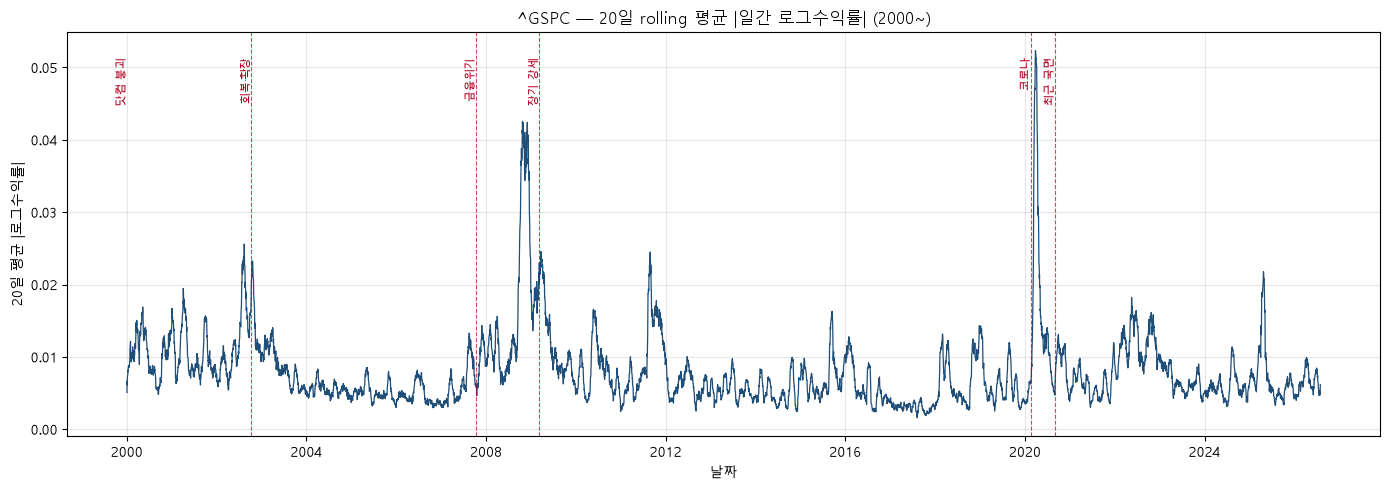

In [11]:
import matplotlib
import matplotlib.pyplot as plt

# 윈도우 기본 폰트에는 한글 글리프가 없어서 축 라벨이 네모(두부)로 깨진다.
matplotlib.rcParams["font.family"] = "Malgun Gothic"
# 한글 폰트를 쓰면 유니코드 마이너스(U+2212) 글리프가 없어 깨지므로 ASCII 하이픈을 쓴다.
matplotlib.rcParams["axes.unicode_minus"] = False

# 신호용 티커만 그린다. 변동성 군집은 가격 자체의 성질이고, ^SP500TR은 배당
# 재투자가 더해진 벤치마크라 신호 관점에서 볼 대상이 아니다 (CLAUDE.md 규칙 5).
signal_df = df.loc[signal_mask]               # -> DataFrame (9212, 9)
signal_df = signal_df.sort_values("date")     # -> DataFrame (9212, 9)
signal_df = signal_df.reset_index(drop=True)  # -> DataFrame (9212, 9)

# rolling은 수집 구간(1990~) 전체에서 먼저 계산한다. 분석 구간(2000~)을 먼저
# 자르고 rolling을 걸면 2000년 첫 19거래일이 NaN이 되어 그림 왼쪽 끝이 비어버린다.
# 지표 워밍업과 완전히 같은 논리다 — 계산은 긴 구간에서, 평가는 짧은 구간에서.
# 이 subset은 티커가 1개이므로 rolling이 티커 경계를 넘을 수 없다.
signal_return = signal_df["log_return"]                  # -> Series[float] (9212,)
absolute_return = signal_return.abs()                    # -> Series[float] (9212,)
window = config.ROLLING_VOL_WINDOW                       # -> int (20)
rolling_window = absolute_return.rolling(window=window)  # -> Rolling
rolling_mean = rolling_window.mean()                     # -> Series[float] (9212,), 앞 19개 NaN
signal_df["rolling_abs_return"] = rolling_mean           # -> DataFrame (9212, 10)

# 계산이 끝난 뒤에 분석 구간을 자른다.
signal_date_column = signal_df["date"]                     # -> Series[datetime64] (9212,)
in_analysis_window = signal_date_column >= analysis_start  # -> Series[bool] (9212,)
plot_df = signal_df.loc[in_analysis_window]                # -> DataFrame (분석 구간 행 수, 10)
plot_df = plot_df.reset_index(drop=True)                   # -> DataFrame (분석 구간 행 수, 10)

figure, axes = plt.subplots(figsize=(14, 5))

plot_x = plot_df["date"]                # -> Series[datetime64]
plot_y = plot_df["rolling_abs_return"]  # -> Series[float]
axes.plot(plot_x, plot_y, linewidth=0.9, color="#1f4e79")

label_y = plot_y.max() * 0.98  # -> numpy.float64, 국면 이름을 그림 위쪽에 붙인다

for phase_key in config.MARKET_REGIMES:
    phase_info = config.MARKET_REGIMES[phase_key]        # -> dict
    start_timestamp = pd.Timestamp(phase_info["start"])  # -> Timestamp

    # 첫 국면 시작일은 그림 왼쪽 끝과 겹치므로 세로선은 긋지 않고 이름만 붙인다.
    if start_timestamp > analysis_start:
        axes.axvline(
            start_timestamp,
            color="#b00020",
            linestyle="--",
            linewidth=0.8,
            alpha=0.7,
        )

    label_x = max(start_timestamp, analysis_start)  # -> Timestamp
    axes.text(
        label_x,
        label_y,
        phase_info["name"],
        rotation=90,
        fontsize=8,
        va="top",
        ha="right",
        color="#b00020",
    )

title_text = f"{signal_ticker} — {window}일 rolling 평균 |일간 로그수익률| ({config.ANALYSIS_START[:4]}~)"
axes.set_title(title_text)
axes.set_xlabel("날짜")
axes.set_ylabel(f"{window}일 평균 |로그수익률|")
axes.grid(alpha=0.3)

figure.tight_layout()

figure_path = config.VOLATILITY_FIGURE_PATH  # -> Path
figure.savefig(figure_path, dpi=150)
print(f"그림 저장: {figure_path}")

plt.show()

## 해석

수치는 `^GSPC`(신호용 티커) 기준. 아래는 표와 그림에서 **읽히는 사실**만 적은
것이고, 해석·판단은 마지막 칸에 직접 채운다.

괄호 안 `SE`는 추정치 ÷ 근사 표준오차다. 이 숫자를 같이 보지 않으면 표본
135일짜리 코로나와 2,756일짜리 장기 강세의 왜도를 같은 신뢰도로 비교하게 된다.

1. **왜도가 가장 음수인 국면은 코로나(-0.69, 3.3 SE)** 로, 다른 국면(+0.15 ~
   -0.21)과 확연히 다르다. 그런데 **닷컴 붕괴는 -47% 하락장인데도 왜도가
   +0.15로 양수**다. 다만 이 값은 **1.6 SE에 불과해 "양수"라고 단정하기엔
   약한 근거**다 — 방향성 힌트로만 다뤄야 한다. 반면 코로나(3.3 SE)와
   장기 강세(-0.21, 4.5 SE)의 음수 왜도는 상대적으로 단단하다.

2. **초과첨도가 가장 큰 국면은 최근 국면(5.82, 45.8 SE)**, 다음이 장기 강세
   (4.97, 53.2 SE)와 코로나(4.89, 11.6 SE)다. 반대로 **닷컴 붕괴가 1.24로
   가장 낮지만 그조차 6.7 SE**다. 즉 **6개 국면 전부 초과첨도가 0보다 크고,
   전부 표준오차 대비 충분히 크다.** 왜도와 달리 이쪽은 표본 잡음으로 설명되지
   않는다 → **어느 국면에서도 일간 수익률은 정규분포가 아니다.**

3. **연율변동성은 국면 간 최대 3.3배 차이** 난다 (회복·확장 13.6% ↔ 코로나 44.8%).
   변동성을 표본 전체 하나의 상수로 가정하면 이 3.3배를 평균 하나로 뭉개게 된다.

4. **rolling 그림에서 변동성 군집이 육안으로 뚜렷하다.** 2004–2007, 2013, 2017
   구간은 0.005 부근에 눌려 있고, 2008–09(약 0.043)와 2020년(약 0.052)에
   봉우리가 솟는다. 다만 **봉우리 높이와 사건의 총 규모는 다른 것을 잰다** —
   높이는 20일 창 안에 큰 변동이 얼마나 빽빽하게 들어찼는지를 재고, 총 규모는
   지속 기간과 MDD를 같이 봐야 한다 (금융위기 MDD -56.7% vs 코로나 -33.7%).

5. 위 군집 구조는 D1 관찰(2008년 상승 충격 7일·하락 충격 11일이 같은 해에 공존)과
   같은 현상을 다른 각도에서 보여준다. → `reports/why_it_fails.md`

**연율로그수익률과 CAGR을 섞어 읽지 말 것.** 표의 `연율로그수익률`은 로그 공간
값이라 복리 수익률이 아니다. 장기 강세 국면은 로그 기준 +14.7%지만 CAGR로는
+15.9%다.

**주의:** 위 국면 구분은 사후적으로 그은 선이다. 2000년 1월에 서 있던 사람은
자기가 "닷컴 붕괴 국면"에 있다는 것을 알 수 없었다. 이 표는 전략을 만드는
재료가 아니라, 전략 성과를 나중에 국면별로 쪼개 볼 때 쓰는 기준선이다.

---

**내 해석 (직접 채울 것):**
